## Tugas 1 Deep Learning


## 1. Data Akuisisi

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda v: f'{v:.6f}')

In [ ]:
column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'label']

raw = pd.read_csv('dataset/data_iris.csv', header=None, names=column_names)

print(f'Jumlah baris : {len(raw)}')
print(f'Kelas        : {raw["label"].unique().tolist()}')
raw.head()

Jumlah baris : 100
Kelas        : ['Iris-setosa', 'Iris-versicolor']


,sepal_length,sepal_width,petal_length,petal_width,label
0,5.100000,3.500000,1.400000,0.200000,Iris-setosa
1,4.900000,3.000000,1.400000,0.200000,Iris-setosa
2,4.700000,3.200000,1.300000,0.200000,Iris-setosa
3,4.600000,3.100000,1.500000,0.200000,Iris-setosa
4,5.000000,3.600000,1.400000,0.200000,Iris-setosa


## 2. Data preprocessing
### Encoding
Karena pada data raw, label target masih berupa data kategorikal (Iris-setosa dan Iris-versicolor). Label target di encoding dengan setosa menjadi 0 dan versicolor menjadi 1

In [12]:
LABEL_MAP = {'Iris-setosa': 0, 'Iris-versicolor': 1}
raw['TARGET'] = raw['label'].map(LABEL_MAP)

raw[['label', 'TARGET']].drop_duplicates()

,label,TARGET
0,Iris-setosa,0
50,Iris-versicolor,1


### Splitting data

Agar sesuai dengan data pada spreadsheets yang diberikan. Data dibagi menjadi dua kelas Iris-setosa dan Iris-versicolor Tiap kelas diambil 40 baris pertama untuk training dan 10 baris sisanya untuk validasi,lalu digabung dengan setosa di atas dan versicolor di bawah.

In [13]:
setosa     = raw[raw['label'] == 'Iris-setosa'].reset_index(drop=True)
versicolor = raw[raw['label'] == 'Iris-versicolor'].reset_index(drop=True)

N_TRAIN_PER_CLASS = 40

train_df = pd.concat([setosa.iloc[:N_TRAIN_PER_CLASS],
                      versicolor.iloc[:N_TRAIN_PER_CLASS]], ignore_index=True)
val_df   = pd.concat([setosa.iloc[N_TRAIN_PER_CLASS:],
                      versicolor.iloc[N_TRAIN_PER_CLASS:]], ignore_index=True)

FEATURES = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X_train = train_df[FEATURES].to_numpy(dtype=float)
y_train = train_df['TARGET'].to_numpy(dtype=float)
X_val   = val_df[FEATURES].to_numpy(dtype=float)
y_val   = val_df['TARGET'].to_numpy(dtype=float)

print(f'Data training  : {len(X_train)} baris  {train_df["label"].value_counts().to_dict()}')
print(f'Data validation: {len(X_val)} baris  {val_df["label"].value_counts().to_dict()}')

Data training  : 80 baris  {'Iris-setosa': 40, 'Iris-versicolor': 40}
Data validation: 20 baris  {'Iris-setosa': 10, 'Iris-versicolor': 10}


In [14]:
print('Baris pertama training  :', X_train[0].tolist(), '-> target', y_train[0])
print('Baris pertama validation:', X_val[0].tolist(),   '-> target', y_val[0])
print()
print('Spreadsheet Data Training  baris 1 : [5.1, 3.5, 1.4, 0.2] target 0')
print('Spreadsheet Data Validation baris 1: [5.0, 3.5, 1.3, 0.3] target 0')

Baris pertama training  : [5.1, 3.5, 1.4, 0.2] -> target 0.0
Baris pertama validation: [5.0, 3.5, 1.3, 0.3] -> target 0.0

Spreadsheet Data Training  baris 1 : [5.1, 3.5, 1.4, 0.2] target 0
Spreadsheet Data Validation baris 1: [5.0, 3.5, 1.3, 0.3] target 0


## 3. Hyperparameter dan fungsi
Kita menginisialisasi bobot awal dengan 0.5 dan sesuai dengan instruksi learning rate bernilai 0.1 kemudian melakukan epoch sebanyak 5. 

In [ ]:
LEARNING_RATE = 0.1
EPOCHS        = 5
INIT_WEIGHT   = 0.5

# fungsi sigmoid g(z)
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

# fungsi dot product (z) untuk validation (bobot sama)
def predict_proba(X, bias, theta):
    return sigmoid(bias + X @ theta)

# fungsi label prediksi, jika probabilitas > threshold maka label 1, jika <= threshold maka label 0
def to_label(a, threshold=0.5):
    return (a > threshold).astype(float)

# fungsi turunan
def grad_wrt_z(a, y):
    return 2.0 * (a - y) * a * (1.0 - a)

## 4. Training loop

In [ ]:
bias  = INIT_WEIGHT
theta = np.full(len(FEATURES), INIT_WEIGHT, dtype=float)

history = {'epoch': [], 'train_acc': [], 'train_loss': [], 'val_acc': [], 'val_loss': []}
weight_log = []
train_log =[]
val_log = []

# loop training per epoch
for epoch in range(1, EPOCHS + 1):
    n_correct = 0
    squared_errors = []

    # fase training (update bobot tiap sampel dengan loop)
    for no, (x, y) in enumerate(zip(X_train, y_train), start=1):
        bias_now, theta_now = bias, theta.copy()
        
        z = bias + np.dot(theta, x)
        a = sigmoid(z)
        pred  = float(to_label(a))
        error = a - y
        sse   = error ** 2

        n_correct += int(to_label(a) == y)
        squared_errors.append((a - y) ** 2)

        train_log.append({
            'Epoch': epoch, 'No': no,
            'X1': x[0], 'X2': x[1], 'X3': x[2], 'X4': x[3], 'TARGET': y,
            'bias': bias_now,
            'teta1': theta_now[0], 'teta2': theta_now[1],
            'teta3': theta_now[2], 'teta4': theta_now[3],
            'z': z, 'g(z)': a, 'Prediksi': pred, 'error': error, 'SSE': sse,
        })

        g = grad_wrt_z(a, y)
        bias  = bias  - LEARNING_RATE * g
        theta = theta - LEARNING_RATE * g * x

    # hitung akurasi dan loss training
    train_acc  = n_correct / len(y_train)
    train_loss = float(np.mean(squared_errors))

    # fase validasi (bobot sama per epoch)
    a_val    = predict_proba(X_val, bias, theta)

    pred_val = to_label(a_val)

    for no in range(len(X_val)):
        val_log.append({
            'Epoch': epoch, 'No': no + 1,
            'X1': X_val[no, 0], 'X2': X_val[no, 1],
            'X3': X_val[no, 2], 'X4': X_val[no, 3], 'TARGET': y_val[no],
            'bias': bias,
            'teta1': theta[0], 'teta2': theta[1],
            'teta3': theta[2], 'teta4': theta[3],
            'z': bias + np.dot(theta, X_val[no]),
            'g(z)': a_val[no], 'Prediksi': pred_val[no],
            'error': a_val[no] - y_val[no], 'SSE': (a_val[no] - y_val[no]) ** 2,
        })
    
    val_acc  = float(np.mean(to_label(a_val) == y_val))
    val_loss = float(np.mean((a_val - y_val) ** 2))

    history['epoch'].append(epoch)
    history['train_acc'].append(train_acc)
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc)
    history['val_loss'].append(val_loss)
    weight_log.append([epoch, bias, *theta])

    print(f'Epoch {epoch} | '
          f'train_acc={train_acc:.4f} train_loss={train_loss:.6f} | '
          f'val_acc={val_acc:.4f} val_loss={val_loss:.6f}')

train_detail = pd.DataFrame(train_log)
val_detail   = pd.DataFrame(val_log)

print()
print(f'Total baris hasil training : {len(train_detail)}  ({EPOCHS} epoch x {len(X_train)} sampel)')
print(f'Total baris hasil validasi : {len(val_detail)}  ({EPOCHS} epoch x {len(X_val)} sampel)')

Epoch 1 | train_acc=0.5250 train_loss=0.449889 | val_acc=0.5000 val_loss=0.328951
Epoch 2 | train_acc=0.9500 train_loss=0.037452 | val_acc=0.5000 val_loss=0.247289
Epoch 3 | train_acc=0.9750 train_loss=0.024372 | val_acc=0.5000 val_loss=0.175892
Epoch 4 | train_acc=0.9750 train_loss=0.017357 | val_acc=0.8500 val_loss=0.119381
Epoch 5 | train_acc=0.9875 train_loss=0.012740 | val_acc=1.0000 val_loss=0.081581

Total baris hasil training : 400  (5 epoch x 80 sampel)
Total baris hasil validasi : 100  (5 epoch x 20 sampel)


## 5. Hasil
### Hasil Training tiap iterasi per-epoch

In [28]:
for epoch in range(1, EPOCHS + 1):
    print(f"\n{'=' * 90}\nEPOCH {epoch} — Hasil Training ({len(X_train)} iterasi)\n{'=' * 90}")
    tabel = train_detail[train_detail['Epoch'] == epoch].reset_index(drop=True)
    display(tabel)


EPOCH 1 — Hasil Training (80 iterasi)


,Epoch,No,X1,X2,X3,X4,TARGET,bias,teta1,teta2,teta3,teta4,z,g(z),Prediksi,error,SSE
0,1,1,5.100000,3.500000,1.400000,0.200000,0.000000,0.500000,0.500000,0.500000,0.500000,0.500000,5.600000,0.996316,1.000000,0.996316,0.992645
1,1,2,4.900000,3.000000,1.400000,0.200000,0.000000,0.499269,0.496270,0.497440,0.498976,0.499854,5.221847,0.994632,1.000000,0.994632,0.989292
2,1,3,4.700000,3.200000,1.300000,0.200000,0.000000,0.498206,0.491065,0.494253,0.497489,0.499641,5.134487,0.994144,1.000000,0.994144,0.988323
3,1,4,4.600000,3.100000,1.500000,0.200000,0.000000,0.497049,0.485625,0.490550,0.495984,0.499410,5.095487,0.993913,1.000000,0.993913,0.987863
4,1,5,5.000000,3.600000,1.400000,0.200000,0.000000,0.495846,0.480093,0.486821,0.494180,0.499169,5.440555,0.995682,1.000000,0.995682,0.991382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,1,76,6.000000,3.400000,4.500000,1.600000,1.000000,0.379408,-0.024612,0.068879,0.520498,0.549877,3.687964,0.975588,1.000000,-0.024412,0.000596
76,1,77,6.700000,3.100000,4.700000,1.500000,1.000000,0.379525,-0.023915,0.069274,0.521021,0.550063,3.707939,0.976059,1.000000,-0.023941,0.000573
77,1,78,6.300000,2.300000,4.400000,1.300000,1.000000,0.379636,-0.023165,0.069621,0.521547,0.550231,3.403931,0.967827,1.000000,-0.032173,0.001035
78,1,79,5.600000,3.000000,4.100000,1.300000,1.000000,0.379837,-0.021903,0.070082,0.522429,0.550491,3.325022,0.965277,1.000000,-0.034723,0.001206



EPOCH 2 — Hasil Training (80 iterasi)


,Epoch,No,X1,X2,X3,X4,TARGET,bias,teta1,teta2,teta3,teta4,z,g(z),Prediksi,error,SSE
0,2,1,5.100000,3.500000,1.400000,0.200000,0.000000,0.380336,-0.019133,0.071447,0.524449,0.551140,1.377277,0.798553,1.000000,0.798553,0.637687
1,2,2,4.900000,3.000000,1.400000,0.200000,0.000000,0.354644,-0.150162,-0.018475,0.488481,0.546002,0.356496,0.588192,1.000000,0.588192,0.345970
2,2,3,4.700000,3.200000,1.300000,0.200000,0.000000,0.326149,-0.289786,-0.103959,0.448588,0.540303,-0.677289,0.336867,0.000000,0.336867,0.113479
3,2,4,4.600000,3.100000,1.500000,0.200000,0.000000,0.311099,-0.360523,-0.152120,0.429023,0.537293,-1.067886,0.255805,0.000000,0.255805,0.065436
4,2,5,5.000000,3.600000,1.400000,0.200000,0.000000,0.301360,-0.405324,-0.182313,0.414413,0.535345,-1.694340,0.155206,0.000000,0.155206,0.024089
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,2,76,6.000000,3.400000,4.500000,1.600000,1.000000,0.341562,-0.098561,-0.078700,0.703346,0.635196,3.663987,0.975010,1.000000,-0.024990,0.000624
76,2,77,6.700000,3.100000,4.700000,1.500000,1.000000,0.341684,-0.097830,-0.078286,0.703894,0.635391,3.704923,0.975989,1.000000,-0.024011,0.000577
77,2,78,6.300000,2.300000,4.400000,1.300000,1.000000,0.341797,-0.097076,-0.077938,0.704423,0.635560,3.476650,0.970016,1.000000,-0.029984,0.000899
78,2,79,5.600000,3.000000,4.100000,1.300000,1.000000,0.341971,-0.095978,-0.077536,0.705191,0.635787,3.289692,0.964074,1.000000,-0.035926,0.001291



EPOCH 3 — Hasil Training (80 iterasi)


,Epoch,No,X1,X2,X3,X4,TARGET,bias,teta1,teta2,teta3,teta4,z,g(z),Prediksi,error,SSE
0,3,1,5.100000,3.500000,1.400000,0.200000,0.000000,0.342472,-0.093195,-0.076158,0.707221,0.636439,0.718024,0.672172,1.000000,0.672172,0.451815
1,3,2,4.900000,3.000000,1.400000,0.200000,0.000000,0.312849,-0.244275,-0.179841,0.665749,0.630514,-0.365468,0.409637,0.000000,0.409637,0.167802
2,3,3,4.700000,3.200000,1.300000,0.200000,0.000000,0.293036,-0.341358,-0.239279,0.638011,0.626551,-1.122314,0.245582,0.000000,0.245582,0.060311
3,3,4,4.600000,3.100000,1.500000,0.200000,0.000000,0.283936,-0.384127,-0.268399,0.626181,0.624731,-1.250867,0.222550,0.000000,0.222550,0.049529
4,3,5,5.000000,3.600000,1.400000,0.200000,0.000000,0.276235,-0.419553,-0.292273,0.614629,0.623191,-1.888590,0.131405,0.000000,0.131405,0.017267
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,3,76,6.000000,3.400000,4.500000,1.600000,1.000000,0.309573,-0.157240,-0.206164,0.862115,0.708185,3.677785,0.975344,1.000000,-0.024656,0.000608
76,3,77,6.700000,3.100000,4.700000,1.500000,1.000000,0.309692,-0.156529,-0.205761,0.862648,0.708374,3.740099,0.976799,1.000000,-0.023201,0.000538
77,3,78,6.300000,2.300000,4.400000,1.300000,1.000000,0.309797,-0.155824,-0.205435,0.863143,0.708532,3.574523,0.972735,1.000000,-0.027265,0.000743
78,3,79,5.600000,3.000000,4.100000,1.300000,1.000000,0.309941,-0.154913,-0.205103,0.863779,0.708720,3.289951,0.964082,1.000000,-0.035918,0.001290



EPOCH 4 — Hasil Training (80 iterasi)


,Epoch,No,X1,X2,X3,X4,TARGET,bias,teta1,teta2,teta3,teta4,z,g(z),Prediksi,error,SSE
0,4,1,5.100000,3.500000,1.400000,0.200000,0.000000,0.310418,-0.152266,-0.203786,0.865711,0.709340,0.174473,0.543508,1.000000,0.543508,0.295401
1,4,2,4.900000,3.000000,1.400000,0.200000,0.000000,0.283448,-0.289811,-0.298180,0.827953,0.703946,-0.731242,0.324922,0.000000,0.324922,0.105574
2,4,3,4.700000,3.200000,1.300000,0.200000,0.000000,0.269194,-0.359657,-0.340943,0.807998,0.701095,-1.321592,0.210553,0.000000,0.210553,0.044333
3,4,4,4.600000,3.100000,1.500000,0.200000,0.000000,0.262195,-0.392555,-0.363342,0.798898,0.699695,-1.331632,0.208890,0.000000,0.208890,0.043635
4,4,5,5.000000,3.600000,1.400000,0.200000,0.000000,0.255291,-0.424313,-0.384744,0.788542,0.698314,-2.007733,0.118393,0.000000,0.118393,0.014017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,4,76,6.000000,3.400000,4.500000,1.600000,1.000000,0.281468,-0.206595,-0.320433,0.999114,0.769685,3.679938,0.975396,1.000000,-0.024604,0.000605
76,4,77,6.700000,3.100000,4.700000,1.500000,1.000000,0.281586,-0.205886,-0.320032,0.999646,0.769874,3.763197,0.977317,1.000000,-0.022683,0.000515
77,4,78,6.300000,2.300000,4.400000,1.300000,1.000000,0.281687,-0.205212,-0.319720,1.000118,0.770025,3.655047,0.974792,1.000000,-0.025208,0.000635
78,4,79,5.600000,3.000000,4.100000,1.300000,1.000000,0.281811,-0.204432,-0.319435,1.000664,0.770186,3.282650,0.963829,1.000000,-0.036171,0.001308



EPOCH 5 — Hasil Training (80 iterasi)


,Epoch,No,X1,X2,X3,X4,TARGET,bias,teta1,teta2,teta3,teta4,z,g(z),Prediksi,error,SSE
0,5,1,5.100000,3.500000,1.400000,0.200000,0.000000,0.282274,-0.201860,-0.318152,1.002541,0.770788,-0.303028,0.424817,0.000000,0.424817,0.180470
1,5,2,4.900000,3.000000,1.400000,0.200000,0.000000,0.261513,-0.307739,-0.390814,0.973476,0.766636,-0.902657,0.288505,0.000000,0.288505,0.083235
2,5,3,4.700000,3.200000,1.300000,0.200000,0.000000,0.249669,-0.365776,-0.426347,0.956894,0.764267,-1.436972,0.192015,0.000000,0.192015,0.036870
3,5,4,4.600000,3.100000,1.500000,0.200000,0.000000,0.243711,-0.393779,-0.445412,0.949149,0.763075,-1.372112,0.202279,0.000000,0.202279,0.040917
4,5,5,5.000000,3.600000,1.400000,0.200000,0.000000,0.237183,-0.423808,-0.465649,0.939357,0.761770,-2.090740,0.110000,0.000000,0.110000,0.012100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,5,76,6.000000,3.400000,4.500000,1.600000,1.000000,0.256980,-0.246141,-0.419009,1.119071,0.823046,3.708199,0.976065,1.000000,-0.023935,0.000573
76,5,77,6.700000,3.100000,4.700000,1.500000,1.000000,0.257092,-0.245470,-0.418629,1.119574,0.823225,3.811533,0.978364,1.000000,-0.021636,0.000468
77,5,78,6.300000,2.300000,4.400000,1.300000,1.000000,0.257184,-0.244856,-0.418345,1.120005,0.823362,3.750790,0.977040,1.000000,-0.022960,0.000527
78,5,79,5.600000,3.000000,4.100000,1.300000,1.000000,0.257287,-0.244207,-0.418108,1.120458,0.823496,3.299827,0.964423,1.000000,-0.035577,0.001266


### Bobot akhir tiap epoch (training)

Nilai bobot akhor tiap epoch pada fase training adalah bobot yang dipakai sebagi bobot tetap untuk fase validasi tiap epoch.

In [18]:
weights_df = pd.DataFrame(weight_log, columns=['epoch', 'bias', 'teta1', 'teta2', 'teta3', 'teta4'])
weights_df.set_index('epoch')

,bias,teta1,teta2,teta3,teta4
epoch,,,,,
1,0.380336,-0.019133,0.071447,0.524449,0.551140
2,0.342472,-0.093195,-0.076158,0.707221,0.636439
3,0.310418,-0.152266,-0.203786,0.865711,0.709340
4,0.282274,-0.201860,-0.318152,1.002541,0.770788
5,0.257720,-0.241802,-0.416903,1.122214,0.824059


### Hasil validasi tiap iterasi per-epoch


In [29]:
for epoch in range(1, EPOCHS + 1):
    print(f"\n{'=' * 90}\nEPOCH {epoch} — Hasil Validasi ({len(X_val)} iterasi)\n{'=' * 90}")
    tabel = val_detail[val_detail['Epoch'] == epoch].reset_index(drop=True)
    display(tabel)


EPOCH 1 — Hasil Validasi (20 iterasi)


,Epoch,No,X1,X2,X3,X4,TARGET,bias,teta1,teta2,teta3,teta4,z,g(z),Prediksi,error,SSE
0,1,1,5.000000,3.500000,1.300000,0.300000,0.000000,0.380336,-0.019133,0.071447,0.524449,0.551140,1.381860,0.799289,1.000000,0.799289,0.638864
1,1,2,4.500000,2.300000,1.300000,0.300000,0.000000,0.380336,-0.019133,0.071447,0.524449,0.551140,1.305690,0.786791,1.000000,0.786791,0.619040
2,1,3,4.400000,3.200000,1.300000,0.200000,0.000000,0.380336,-0.019133,0.071447,0.524449,0.551140,1.316792,0.788647,1.000000,0.788647,0.621965
3,1,4,5.000000,3.500000,1.600000,0.600000,0.000000,0.380336,-0.019133,0.071447,0.524449,0.551140,1.704536,0.846126,1.000000,0.846126,0.715930
4,1,5,5.100000,3.800000,1.900000,0.400000,0.000000,0.380336,-0.019133,0.071447,0.524449,0.551140,1.771164,0.854602,1.000000,0.854602,0.730345
5,1,6,4.800000,3.000000,1.400000,0.300000,0.000000,0.380336,-0.019133,0.071447,0.524449,0.551140,1.402408,0.802566,1.000000,0.802566,0.644112
6,1,7,5.100000,3.800000,1.600000,0.200000,0.000000,0.380336,-0.019133,0.071447,0.524449,0.551140,1.503601,0.818111,1.000000,0.818111,0.669306
7,1,8,4.600000,3.200000,1.400000,0.200000,0.000000,0.380336,-0.019133,0.071447,0.524449,0.551140,1.365410,0.796638,1.000000,0.796638,0.634631
8,1,9,5.300000,3.700000,1.500000,0.200000,0.000000,0.380336,-0.019133,0.071447,0.524449,0.551140,1.440185,0.808483,1.000000,0.808483,0.653645
9,1,10,5.000000,3.300000,1.400000,0.200000,0.000000,0.380336,-0.019133,0.071447,0.524449,0.551140,1.364901,0.796555,1.000000,0.796555,0.634500



EPOCH 2 — Hasil Validasi (20 iterasi)


,Epoch,No,X1,X2,X3,X4,TARGET,bias,teta1,teta2,teta3,teta4,z,g(z),Prediksi,error,SSE
0,2,1,5.000000,3.500000,1.300000,0.300000,0.000000,0.342472,-0.093195,-0.076158,0.707221,0.636439,0.720265,0.672665,1.000000,0.672665,0.452479
1,2,2,4.500000,2.300000,1.300000,0.300000,0.000000,0.342472,-0.093195,-0.076158,0.707221,0.636439,0.858253,0.702295,1.000000,0.702295,0.493219
2,2,3,4.400000,3.200000,1.300000,0.200000,0.000000,0.342472,-0.093195,-0.076158,0.707221,0.636439,0.735386,0.675986,1.000000,0.675986,0.456957
3,2,4,5.000000,3.500000,1.600000,0.600000,0.000000,0.342472,-0.093195,-0.076158,0.707221,0.636439,1.123363,0.754612,1.000000,0.754612,0.569439
4,2,5,5.100000,3.800000,1.900000,0.400000,0.000000,0.342472,-0.093195,-0.076158,0.707221,0.636439,1.176075,0.764241,1.000000,0.764241,0.584065
5,2,6,4.800000,3.000000,1.400000,0.300000,0.000000,0.342472,-0.093195,-0.076158,0.707221,0.636439,0.847706,0.700086,1.000000,0.700086,0.490120
6,2,7,5.100000,3.800000,1.600000,0.200000,0.000000,0.342472,-0.093195,-0.076158,0.707221,0.636439,0.836621,0.697753,1.000000,0.697753,0.486859
7,2,8,4.600000,3.200000,1.400000,0.200000,0.000000,0.342472,-0.093195,-0.076158,0.707221,0.636439,0.787469,0.687288,1.000000,0.687288,0.472364
8,2,9,5.300000,3.700000,1.500000,0.200000,0.000000,0.342472,-0.093195,-0.076158,0.707221,0.636439,0.754876,0.680240,1.000000,0.680240,0.462727
9,2,10,5.000000,3.300000,1.400000,0.200000,0.000000,0.342472,-0.093195,-0.076158,0.707221,0.636439,0.742575,0.677559,1.000000,0.677559,0.459086



EPOCH 3 — Hasil Validasi (20 iterasi)


,Epoch,No,X1,X2,X3,X4,TARGET,bias,teta1,teta2,teta3,teta4,z,g(z),Prediksi,error,SSE
0,3,1,5.000000,3.500000,1.300000,0.300000,0.000000,0.310418,-0.152266,-0.203786,0.865711,0.709340,0.174062,0.543406,1.000000,0.543406,0.295290
1,3,2,4.500000,2.300000,1.300000,0.300000,0.000000,0.310418,-0.152266,-0.203786,0.865711,0.709340,0.494739,0.621222,1.000000,0.621222,0.385917
2,3,3,4.400000,3.200000,1.300000,0.200000,0.000000,0.310418,-0.152266,-0.203786,0.865711,0.709340,0.255624,0.563560,1.000000,0.563560,0.317600
3,3,4,5.000000,3.500000,1.600000,0.600000,0.000000,0.310418,-0.152266,-0.203786,0.865711,0.709340,0.646577,0.656239,1.000000,0.656239,0.430649
4,3,5,5.100000,3.800000,1.900000,0.400000,0.000000,0.310418,-0.152266,-0.203786,0.865711,0.709340,0.688060,0.665535,1.000000,0.665535,0.442937
5,3,6,4.800000,3.000000,1.400000,0.300000,0.000000,0.310418,-0.152266,-0.203786,0.865711,0.709340,0.392980,0.597000,1.000000,0.597000,0.356409
6,3,7,5.100000,3.800000,1.600000,0.200000,0.000000,0.310418,-0.152266,-0.203786,0.865711,0.709340,0.286479,0.571134,1.000000,0.571134,0.326194
7,3,8,4.600000,3.200000,1.400000,0.200000,0.000000,0.310418,-0.152266,-0.203786,0.865711,0.709340,0.311742,0.577310,1.000000,0.577310,0.333287
8,3,9,5.300000,3.700000,1.500000,0.200000,0.000000,0.310418,-0.152266,-0.203786,0.865711,0.709340,0.189833,0.547316,1.000000,0.547316,0.299555
9,3,10,5.000000,3.300000,1.400000,0.200000,0.000000,0.310418,-0.152266,-0.203786,0.865711,0.709340,0.230457,0.557361,1.000000,0.557361,0.310651



EPOCH 4 — Hasil Validasi (20 iterasi)


,Epoch,No,X1,X2,X3,X4,TARGET,bias,teta1,teta2,teta3,teta4,z,g(z),Prediksi,error,SSE
0,4,1,5.000000,3.500000,1.300000,0.300000,0.000000,0.282274,-0.201860,-0.318152,1.002541,0.770788,-0.306017,0.424087,0.000000,0.424087,0.179850
1,4,2,4.500000,2.300000,1.300000,0.300000,0.000000,0.282274,-0.201860,-0.318152,1.002541,0.770788,0.176695,0.544059,1.000000,0.544059,0.296000
2,4,3,4.400000,3.200000,1.300000,0.200000,0.000000,0.282274,-0.201860,-0.318152,1.002541,0.770788,-0.166534,0.458462,0.000000,0.458462,0.210188
3,4,4,5.000000,3.500000,1.600000,0.600000,0.000000,0.282274,-0.201860,-0.318152,1.002541,0.770788,0.225981,0.556256,1.000000,0.556256,0.309421
4,4,5,5.100000,3.800000,1.900000,0.400000,0.000000,0.282274,-0.201860,-0.318152,1.002541,0.770788,0.256955,0.563888,1.000000,0.563888,0.317969
5,4,6,4.800000,3.000000,1.400000,0.300000,0.000000,0.282274,-0.201860,-0.318152,1.002541,0.770788,-0.006315,0.498421,0.000000,0.498421,0.248424
6,4,7,5.100000,3.800000,1.600000,0.200000,0.000000,0.282274,-0.201860,-0.318152,1.002541,0.770788,-0.197965,0.450670,0.000000,0.450670,0.203103
7,4,8,4.600000,3.200000,1.400000,0.200000,0.000000,0.282274,-0.201860,-0.318152,1.002541,0.770788,-0.106652,0.473362,0.000000,0.473362,0.224072
8,4,9,5.300000,3.700000,1.500000,0.200000,0.000000,0.282274,-0.201860,-0.318152,1.002541,0.770788,-0.306776,0.423902,0.000000,0.423902,0.179693
9,4,10,5.000000,3.300000,1.400000,0.200000,0.000000,0.282274,-0.201860,-0.318152,1.002541,0.770788,-0.219211,0.445416,0.000000,0.445416,0.198395



EPOCH 5 — Hasil Validasi (20 iterasi)


,Epoch,No,X1,X2,X3,X4,TARGET,bias,teta1,teta2,teta3,teta4,z,g(z),Prediksi,error,SSE
0,5,1,5.000000,3.500000,1.300000,0.300000,0.000000,0.257720,-0.241802,-0.416903,1.122214,0.824059,-0.704355,0.330847,0.000000,0.330847,0.109460
1,5,2,4.500000,2.300000,1.300000,0.300000,0.000000,0.257720,-0.241802,-0.416903,1.122214,0.824059,-0.083170,0.479219,0.000000,0.479219,0.229651
2,5,3,4.400000,3.200000,1.300000,0.200000,0.000000,0.257720,-0.241802,-0.416903,1.122214,0.824059,-0.516609,0.373646,0.000000,0.373646,0.139611
3,5,4,5.000000,3.500000,1.600000,0.600000,0.000000,0.257720,-0.241802,-0.416903,1.122214,0.824059,-0.120473,0.469918,0.000000,0.469918,0.220823
4,5,5,5.100000,3.800000,1.900000,0.400000,0.000000,0.257720,-0.241802,-0.416903,1.122214,0.824059,-0.097872,0.475551,0.000000,0.475551,0.226149
5,5,6,4.800000,3.000000,1.400000,0.300000,0.000000,0.257720,-0.241802,-0.416903,1.122214,0.824059,-0.335322,0.416946,0.000000,0.416946,0.173844
6,5,7,5.100000,3.800000,1.600000,0.200000,0.000000,0.257720,-0.241802,-0.416903,1.122214,0.824059,-0.599348,0.354493,0.000000,0.354493,0.125665
7,5,8,4.600000,3.200000,1.400000,0.200000,0.000000,0.257720,-0.241802,-0.416903,1.122214,0.824059,-0.452748,0.388708,0.000000,0.388708,0.151094
8,5,9,5.300000,3.700000,1.500000,0.200000,0.000000,0.257720,-0.241802,-0.416903,1.122214,0.824059,-0.718239,0.327781,0.000000,0.327781,0.107440
9,5,10,5.000000,3.300000,1.400000,0.200000,0.000000,0.257720,-0.241802,-0.416903,1.122214,0.824059,-0.591159,0.356369,0.000000,0.356369,0.126999


### hasil perbandingan akurasi dan loss

tabel berikut adalah perbandingan data validasi dan data training dalam matriks akurasi dan loss per-epoch

In [17]:
hist_df = pd.DataFrame(history).set_index('epoch')
hist_df

,train_acc,train_loss,val_acc,val_loss
epoch,,,,
1,0.525000,0.449889,0.500000,0.328951
2,0.950000,0.037452,0.500000,0.247289
3,0.975000,0.024372,0.500000,0.175892
4,0.975000,0.017357,0.850000,0.119381
5,0.987500,0.012740,1.000000,0.081581


### perbandingan dengan spreadsheets
Angka pembanding ini di salin langsung dari spreadsheet dan dibandingkan dengan hasil dari code dengan menghitung selisih. Selisih harusnya bernilai nol atau sekedar galat pembuatan floating point.

In [19]:
gsheet = pd.DataFrame({
    'train_acc':  [0.5250, 0.9500, 0.9750, 0.9750, 0.9875],
    'train_loss': [0.449889, 0.037452, 0.024372, 0.017357, 0.012740],
    'val_acc':    [0.5000, 0.5000, 0.5000, 0.8500, 1.0000],
    'val_loss':   [0.328951, 0.247289, 0.175892, 0.119381, 0.081581],
}, index=range(1, EPOCHS + 1))
gsheet.index.name = 'epoch'

selisih = (hist_df - gsheet).abs()
print('Selisih maksimum terhadap spreadsheet:', selisih.to_numpy().max())
print('Cocok (toleransi 1e-5):', bool((selisih < 1e-5).all().all()))
selisih

Selisih maksimum terhadap spreadsheet: 3.7329297318533516e-07
Cocok (toleransi 1e-5): True


,train_acc,train_loss,val_acc,val_loss
epoch,,,,
1,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000


## 6. Visualisasi

### Grafik akurasi 

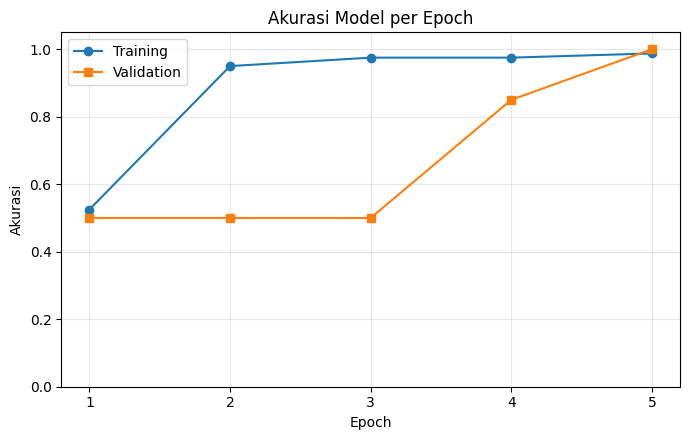

In [20]:
plt.figure(figsize=(7, 4.5))
plt.plot(hist_df.index, hist_df['train_acc'], marker='o', label='Training')
plt.plot(hist_df.index, hist_df['val_acc'], marker='s', label='Validation')
plt.title('Akurasi Model per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.xticks(hist_df.index)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('accuracy_chart.png', dpi=150)
plt.show()

### Grafik loss

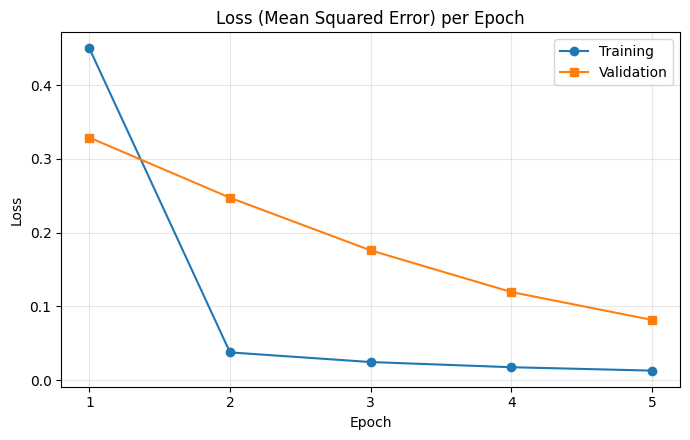

In [21]:
plt.figure(figsize=(7, 4.5))
plt.plot(hist_df.index, hist_df['train_loss'], marker='o', label='Training')
plt.plot(hist_df.index, hist_df['val_loss'], marker='s', label='Validation')
plt.title('Loss (Mean Squared Error) per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(hist_df.index)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('loss_chart.png', dpi=150)
plt.show()